In [207]:
# 1. IMPORT ALL REGRESSION MODELS AND METRICS
from sklearn.linear_model import LinearRegression  # Switched from Logistic
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, VotingRegressor, StackingRegressor
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from sklearn.model_selection import train_test_split
# Regression evaluation metrics (Switched from accuracy/ROC)
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score  
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import xgboost as xgb
import numpy as np
%matplotlib inline


In [208]:
train_df = pd.read_csv(r"C:\Users\ashis\Desktop\python\MLX Session Zero\train_df_1.csv")
test_df = pd.read_csv(r"C:\Users\ashis\Desktop\python\MLX Session Zero\test_df_1.csv")
test_df1 = pd.read_csv(r"C:\Users\ashis\Desktop\python\MLX Session Zero\test_df_1.csv")

In [209]:
submission = test_df["ID"]

##### >>In this part we are doing the EDA on our data<<>>
##### >>extract all the new column from the date time and sunrise and sunset UNIXtime<<>>

In [210]:
train_df.drop(columns=["ID"],inplace=True)
test_df.drop(columns=["ID"],inplace=True)
train_df = train_df.drop_duplicates()
# test_df = test_df.drop_duplicates()

In [211]:
train_df.describe()

,UNIXTime,Radiation,Temperature,Pressure,Humidity,WindDirection(Degrees),Speed
count,1.974700e+04,19747.000000,18741.000000,18736.000000,18747.000000,19747.000000,18811.000000
mean,1.478029e+09,205.271951,51.573536,30.423273,75.734173,144.198271,6.298870
std,3.003402e+06,314.298212,8.158206,0.054410,27.881605,83.663330,3.586696
min,1.472724e+09,-24.151268,35.000000,30.190000,11.000000,0.090000,0.000000
25%,1.475542e+09,1.036427,46.000000,30.400000,55.000000,82.935000,3.370000
50%,1.478008e+09,10.126265,50.000000,30.430000,85.000000,148.110000,5.620000
75%,1.480455e+09,351.413522,55.000000,30.460000,98.000000,179.840000,7.870000
max,1.483264e+09,1609.023851,164.011466,30.560000,254.663813,359.940000,40.500000


In [212]:
train_df.describe()

,UNIXTime,Radiation,Temperature,Pressure,Humidity,WindDirection(Degrees),Speed
count,1.974700e+04,19747.000000,18741.000000,18736.000000,18747.000000,19747.000000,18811.000000
mean,1.478029e+09,205.271951,51.573536,30.423273,75.734173,144.198271,6.298870
std,3.003402e+06,314.298212,8.158206,0.054410,27.881605,83.663330,3.586696
min,1.472724e+09,-24.151268,35.000000,30.190000,11.000000,0.090000,0.000000
25%,1.475542e+09,1.036427,46.000000,30.400000,55.000000,82.935000,3.370000
50%,1.478008e+09,10.126265,50.000000,30.430000,85.000000,148.110000,5.620000
75%,1.480455e+09,351.413522,55.000000,30.460000,98.000000,179.840000,7.870000
max,1.483264e+09,1609.023851,164.011466,30.560000,254.663813,359.940000,40.500000


In [213]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 19747 entries, 0 to 20003
Data columns (total 11 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   UNIXTime                19747 non-null  int64  
 1   Data                    19747 non-null  object 
 2   Time                    19747 non-null  object 
 3   Radiation               19747 non-null  float64
 4   Temperature             18741 non-null  float64
 5   Pressure                18736 non-null  float64
 6   Humidity                18747 non-null  float64
 7   WindDirection(Degrees)  19747 non-null  float64
 8   Speed                   18811 non-null  float64
 9   TimeSunRise             19747 non-null  object 
 10  TimeSunSet              19747 non-null  object 
dtypes: float64(6), int64(1), object(4)
memory usage: 1.8+ MB


## Here We handle the missing values in the data 

In [214]:
print(f"The shape of dataset > {train_df.shape}")
print(f"The shape of dataset > {test_df.shape}")
print(f"Missing Values in the dataset train<---------->\n{train_df.isnull().sum()}")


The shape of dataset > (19747, 11)
The shape of dataset > (3334, 10)
Missing Values in the dataset train<---------->
UNIXTime                     0
Data                         0
Time                         0
Radiation                    0
Temperature               1006
Pressure                  1011
Humidity                  1000
WindDirection(Degrees)       0
Speed                      936
TimeSunRise                  0
TimeSunSet                   0
dtype: int64


In [215]:
print(f"Missing Values in the dataset test<----------->\n{test_df.isnull().sum()}")

Missing Values in the dataset test<----------->
UNIXTime                    0
Data                        0
Time                        0
Temperature               155
Pressure                  154
Humidity                  178
WindDirection(Degrees)      0
Speed                     156
TimeSunRise                 0
TimeSunSet                  0
dtype: int64


In [216]:
# We have 4 column for the filling the missing value
train_df["Temperature"].describe()

count    18741.000000
mean        51.573536
std          8.158206
min         35.000000
25%         46.000000
50%         50.000000
75%         55.000000
max        164.011466
Name: Temperature, dtype: float64

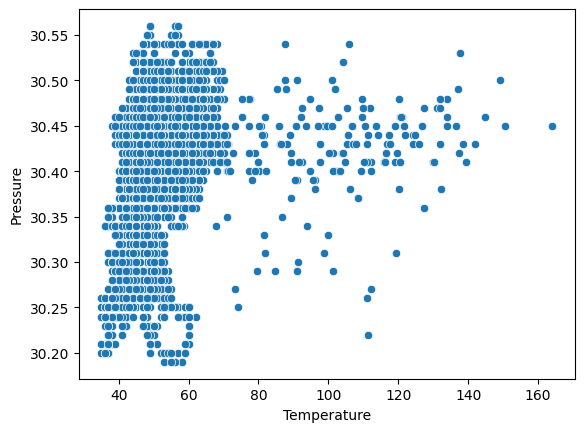

In [217]:
sns.scatterplot(y="Pressure",x="Temperature",data=train_df)
plt.show()

In [218]:
# List of your columns with missing values
columns_to_fill = ['Temperature', 'Pressure', 'Speed', 'Humidity']

for col in columns_to_fill:
    # 1. Calculate the median from the training set
    col_median = train_df[col].median()
    
    # 2. Fill missing values in train_df
    train_df[col] = train_df[col].fillna(col_median)
    
    # 3. Fill missing values in test_df using the same median
    test_df[col] = test_df[col].fillna(col_median)

print("Missing values filled successfully using column medians.")

Missing values filled successfully using column medians.


In [219]:
# detect the Ountliers in the dataset
import pandas as pd
import numpy as np

# List of columns you want to scan for outliers
columns_to_check = ['Temperature', 'Pressure', 'Speed', 'Humidity']

print("--- Outlier Detection Report ---")

for col in columns_to_check:
    # 1. Calculate percentiles
    q1 = train_df[col].quantile(0.25)
    q3 = train_df[col].quantile(0.75)
    
    # 2. Calculate IQR
    iqr = q3 - q1
    
    # 3. Determine safe bounds
    lower_bound = q1 - (1.5 * iqr)
    upper_bound = q3 + (1.5 * iqr)
    
    # 4. Filter the outliers
    outliers = train_df[(train_df[col] < lower_bound) | (train_df[col] > upper_bound)]
    
    print(f"\nCol: {col}")
    print(f"  Safe Range: [{lower_bound:.2f} to {upper_bound:.2f}]")
    print(f"  Total Outliers Detected: {len(outliers)} rows")
    if len(outliers) > 0:
        print(f"  Max Outlier Value: {outliers[col].max()}")
        print(f"  Min Outlier Value: {outliers[col].min()}")

--- Outlier Detection Report ---

Col: Temperature
  Safe Range: [35.00 to 67.00]
  Total Outliers Detected: 255 rows
  Max Outlier Value: 164.0114655
  Min Outlier Value: 67.94166201

Col: Pressure
  Safe Range: [30.31 to 30.55]
  Total Outliers Detected: 951 rows
  Max Outlier Value: 30.56
  Min Outlier Value: 30.19

Col: Speed
  Safe Range: [-0.55 to 12.93]
  Total Outliers Detected: 748 rows
  Max Outlier Value: 40.5
  Min Outlier Value: 13.11495066

Col: Humidity
  Safe Range: [-3.00 to 157.00]
  Total Outliers Detected: 108 rows
  Max Outlier Value: 254.6638125
  Min Outlier Value: 157.3925167


In [220]:
from sklearn.preprocessing import RobustScaler

features_to_scale = [
    'Temperature',
    'Pressure',
    'Speed',
    'Humidity'
]

robust_scaler = RobustScaler()

# Fit only on training data
train_df[features_to_scale] = robust_scaler.fit_transform(
    train_df[features_to_scale]
)

# Transform test data using same scaler
test_df[features_to_scale] = robust_scaler.transform(
    test_df[features_to_scale]
)

print("Scaling completed")

Scaling completed


In [221]:
columns_to_handle = ['Temperature', 'Pressure', 'Speed', 'Humidity']

for col in columns_to_handle:
    # Calculate limits using the standard IQR rule
    q1 = train_df[col].quantile(0.25)
    q3 = train_df[col].quantile(0.85)
    iqr = q3 - q1
    
    lower_bound = q1 - (1.5 * iqr)
    upper_bound = q3 + (1.5 * iqr)
    
    # .clip() instantly locks values into the safe [lower, upper] range
    train_df[col] = train_df[col].clip(lower_bound, upper_bound)
    test_df[col] = test_df[col].clip(lower_bound, upper_bound)

print("Outliers cleanly capped.")

Outliers cleanly capped.


# Feature Engineering 

In [222]:
from datetime import datetime


In [223]:

# plt.figure(figsize=(20,10))
# sns.pairplot(train_df)


In [224]:
print(train_df.duplicated().sum())
print(test_df.duplicated().sum())

0
4


In [225]:
time_cols = ['Time', 'TimeSunRise', 'TimeSunSet']

# Convert Date column
train_df['Data'] = pd.to_datetime(train_df['Data'])
test_df['Data'] = pd.to_datetime(test_df['Data'])



C:\Users\ashis\AppData\Local\Temp\ipykernel_16440\3837070059.py:4: UserWarning: Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  train_df['Data'] = pd.to_datetime(train_df['Data'])
C:\Users\ashis\AppData\Local\Temp\ipykernel_16440\3837070059.py:5: UserWarning: Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  test_df['Data'] = pd.to_datetime(test_df['Data'])


In [226]:
train_df['UNIXTime'] = pd.to_datetime(train_df['UNIXTime'], unit='s')
test_df['UNIXTime'] = pd.to_datetime(test_df['UNIXTime'], unit='s')

In [227]:
train_df['Unix_Hour'] = train_df['UNIXTime'].dt.hour
train_df['Unix_Month'] = train_df['UNIXTime'].dt.month
train_df["Unix_Week_day"] = train_df["UNIXTime"].dt.weekday
train_df['Weekend'] = (train_df['UNIXTime'].dt.weekday >= 5).astype(int)


test_df['Unix_Hour'] = test_df['UNIXTime'].dt.hour
test_df['Unix_Month'] = test_df['UNIXTime'].dt.month
test_df["Unix_Week_day"] = test_df["UNIXTime"].dt.weekday
test_df['Weekend'] = (test_df['UNIXTime'].dt.weekday >= 5).astype(int)


In [228]:

train_df['Hour_sin'] = np.sin(
    2 * np.pi * train_df['Unix_Hour'] / 24
)

train_df['Hour_cos'] = np.cos(
    2 * np.pi * train_df['Unix_Hour'] / 24
)

test_df['Hour_sin'] = np.sin(
    2 * np.pi * test_df['Unix_Hour'] / 24
)

test_df['Hour_cos'] = np.cos(
    2 * np.pi * test_df['Unix_Hour'] / 24
)

train_df['Month_sin'] = np.sin(
    2 * np.pi * train_df['Unix_Month'] / 12
)

train_df['Month_cos'] = np.cos(
    2 * np.pi * train_df['Unix_Month'] / 12
)

test_df['Month_sin'] = np.sin(
    2 * np.pi * test_df['Unix_Month'] / 12
)

test_df['Month_cos'] = np.cos(
    2 * np.pi * test_df['Unix_Month'] / 12
)

In [229]:
train_df.drop(columns=["UNIXTime"],inplace=True)
test_df.drop(columns=["UNIXTime"],inplace=True)

In [230]:
sunrise = pd.to_datetime(train_df['TimeSunRise'].astype(str))
sunset = pd.to_datetime(train_df['TimeSunSet'].astype(str))

train_df['DayLength_Hours'] = (
    (sunset - sunrise).dt.total_seconds() / 3600
)

train_df['SunRiseHour'] = sunrise.dt.hour
train_df['SunSetHour'] = sunset.dt.hour

train_df['SunRiseDecimal'] = (
    sunrise.dt.hour + sunrise.dt.minute / 60
)

train_df['SunSetDecimal'] = (
    sunset.dt.hour + sunset.dt.minute / 60
)

sunrise = pd.to_datetime(test_df['TimeSunRise'].astype(str))
sunset = pd.to_datetime(test_df['TimeSunSet'].astype(str))

test_df['DayLength_Hours'] = (
    (sunset - sunrise).dt.total_seconds() / 3600
)

test_df['SunRiseHour'] = sunrise.dt.hour
test_df['SunSetHour'] = sunset.dt.hour

test_df['SunRiseDecimal'] = (
    sunrise.dt.hour + sunrise.dt.minute / 60
)

test_df['SunSetDecimal'] = (
    sunset.dt.hour + sunset.dt.minute / 60
)

C:\Users\ashis\AppData\Local\Temp\ipykernel_16440\578524462.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  sunrise = pd.to_datetime(train_df['TimeSunRise'].astype(str))
C:\Users\ashis\AppData\Local\Temp\ipykernel_16440\578524462.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  sunset = pd.to_datetime(train_df['TimeSunSet'].astype(str))
C:\Users\ashis\AppData\Local\Temp\ipykernel_16440\578524462.py:19: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  sunrise = pd.to_datetime(test_df['TimeSunRise'].astype(str))
C:\Users\ashis\AppData\Local\Temp\ipykernel_16440\578524462.

In [231]:
train_df.drop(
    ['SunRiseHour', 'SunSetHour'],
    axis=1,
    inplace=True
)

test_df.drop(
    ['SunRiseHour', 'SunSetHour'],
    axis=1,
    inplace=True
)

In [232]:

pd.set_option('display.max_columns', None)

In [233]:
train_df['Time'] = pd.to_datetime(
    train_df['Time'],
    format='%H:%M:%S'
)

test_df['Time'] = pd.to_datetime(
    test_df['Time'],
    format='%H:%M:%S'
)

In [234]:
train_df['Month'] = train_df['Data'].dt.month
train_df['WeekDay'] = train_df['Data'].dt.weekday
train_df['Weekend_time'] = (
    train_df['Data'].dt.weekday >= 5
).astype(int)

train_df['Hour'] = train_df['Time'].apply(lambda x: x.hour)


test_df['Month'] = test_df['Data'].dt.month
test_df['WeekDay'] = test_df['Data'].dt.weekday
test_df['Weekend_time'] = (
    test_df['Data'].dt.weekday >= 5
).astype(int)

test_df['Hour'] = test_df['Time'].apply(lambda x: x.hour)



In [235]:
train_df.drop(
    ['Month', 'WeekDay', 'Weekend_time', 'Hour'],
    axis=1,
    inplace=True
)

test_df.drop(
    ['Month', 'WeekDay', 'Weekend_time', 'Hour'],
    axis=1,
    inplace=True
)

In [236]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 19747 entries, 0 to 20003
Data columns (total 21 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   Data                    19747 non-null  datetime64[ns]
 1   Time                    19747 non-null  datetime64[ns]
 2   Radiation               19747 non-null  float64       
 3   Temperature             19747 non-null  float64       
 4   Pressure                19747 non-null  float64       
 5   Humidity                19747 non-null  float64       
 6   WindDirection(Degrees)  19747 non-null  float64       
 7   Speed                   19747 non-null  float64       
 8   TimeSunRise             19747 non-null  object        
 9   TimeSunSet              19747 non-null  object        
 10  Unix_Hour               19747 non-null  int32         
 11  Unix_Month              19747 non-null  int32         
 12  Unix_Week_day           19747 non-null  int32      

##### Understand of coolumn from the plot how the trend is going for the Radiation column with respect to the another columns

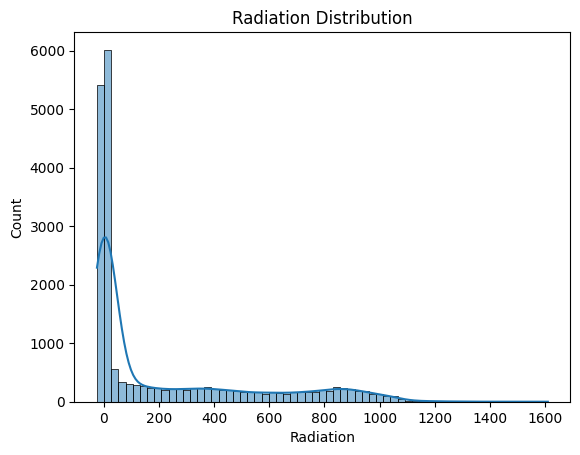

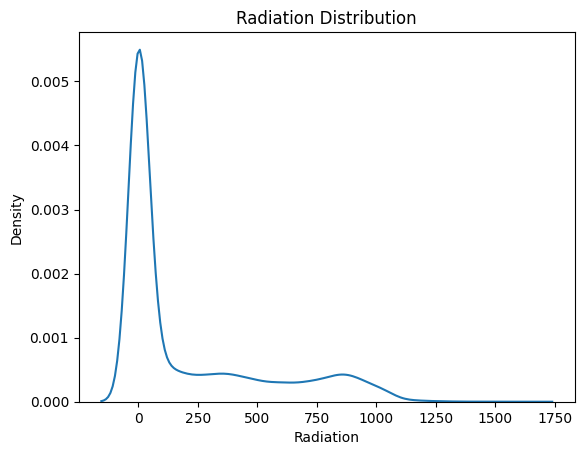

In [237]:
sns.histplot(train_df['Radiation'],kde=True)
plt.title('Radiation Distribution')
plt.show()
sns.kdeplot(train_df['Radiation'])
plt.title('Radiation Distribution')
plt.show()

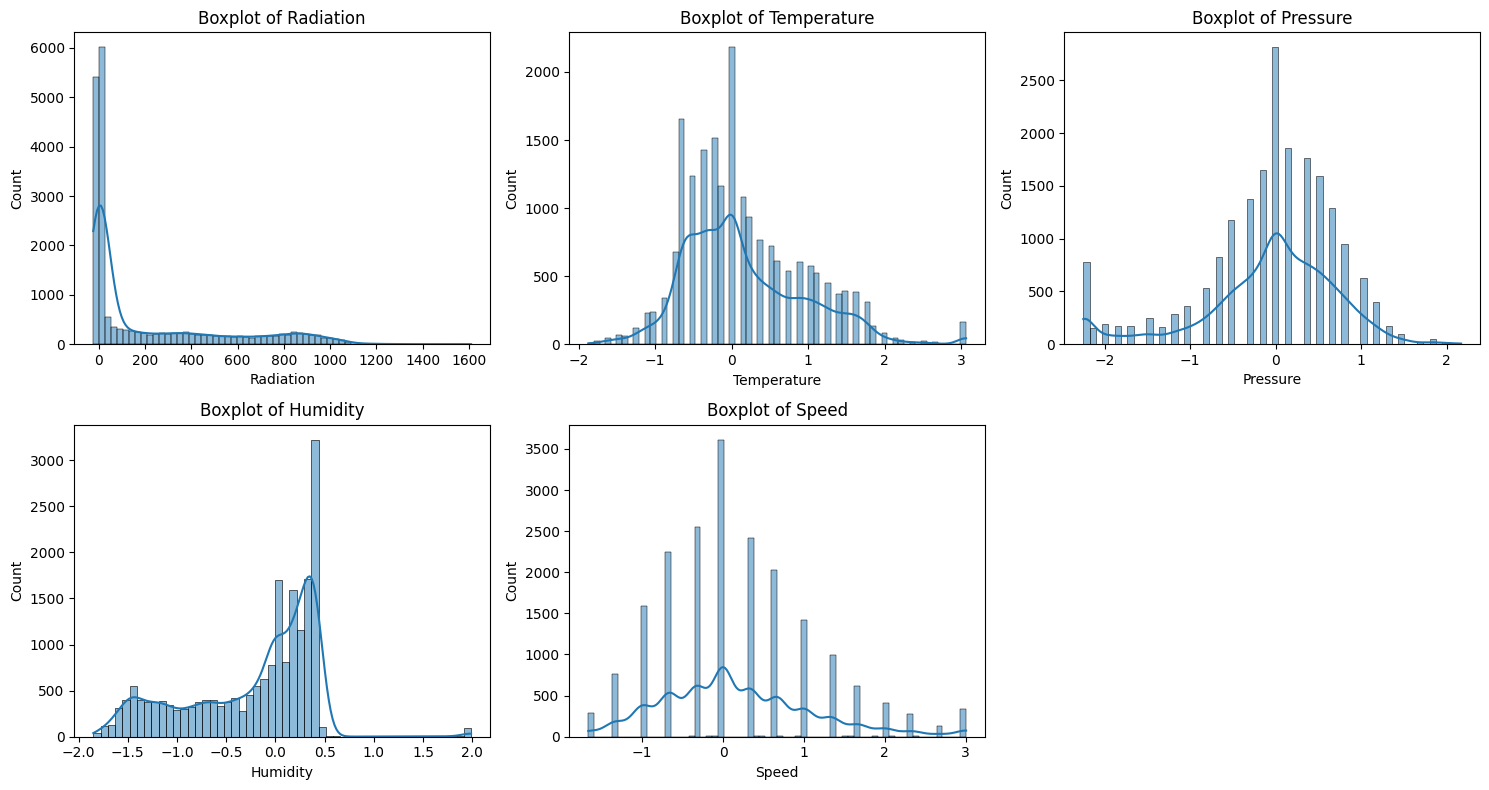

In [238]:
cols = [
    'Radiation',
    'Temperature',
    'Pressure',
    'Humidity',
    'Speed'
]
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()
for i, col in enumerate(cols):
    sns.histplot(
        x=train_df[col],
        ax=axes[i],
        kde=True
    )
    axes[i].set_title(f'Boxplot of {col}')
# Remove empty subplot
fig.delaxes(axes[5])
plt.tight_layout()
plt.show()

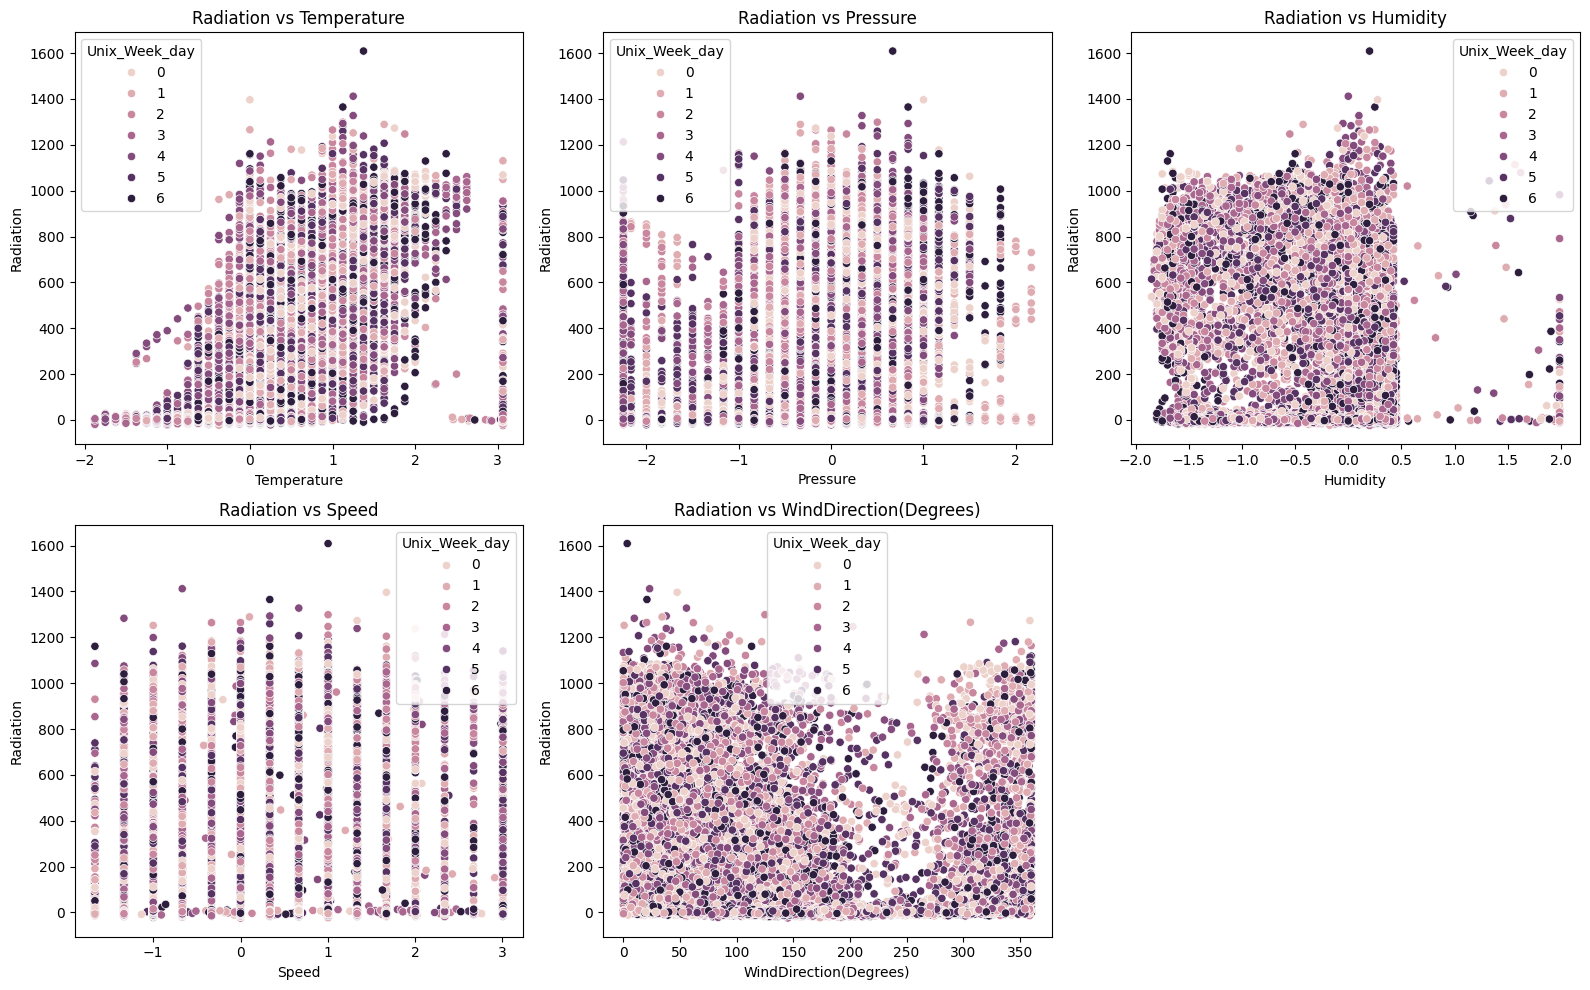

In [239]:
cols = [
    'Temperature',
    'Pressure',
    'Humidity',
    'Speed',
    'WindDirection(Degrees)'
]

fig, axes = plt.subplots(2, 3, figsize=(16,10))

axes = axes.flatten()

for i, col in enumerate(cols):

    sns.scatterplot(
        data=train_df,
        x=col,
        y='Radiation',
        hue='Unix_Week_day',
        ax=axes[i]
    )

    axes[i].set_title(f'Radiation vs {col}')

# Remove empty subplot
fig.delaxes(axes[5])

plt.tight_layout()

plt.show()

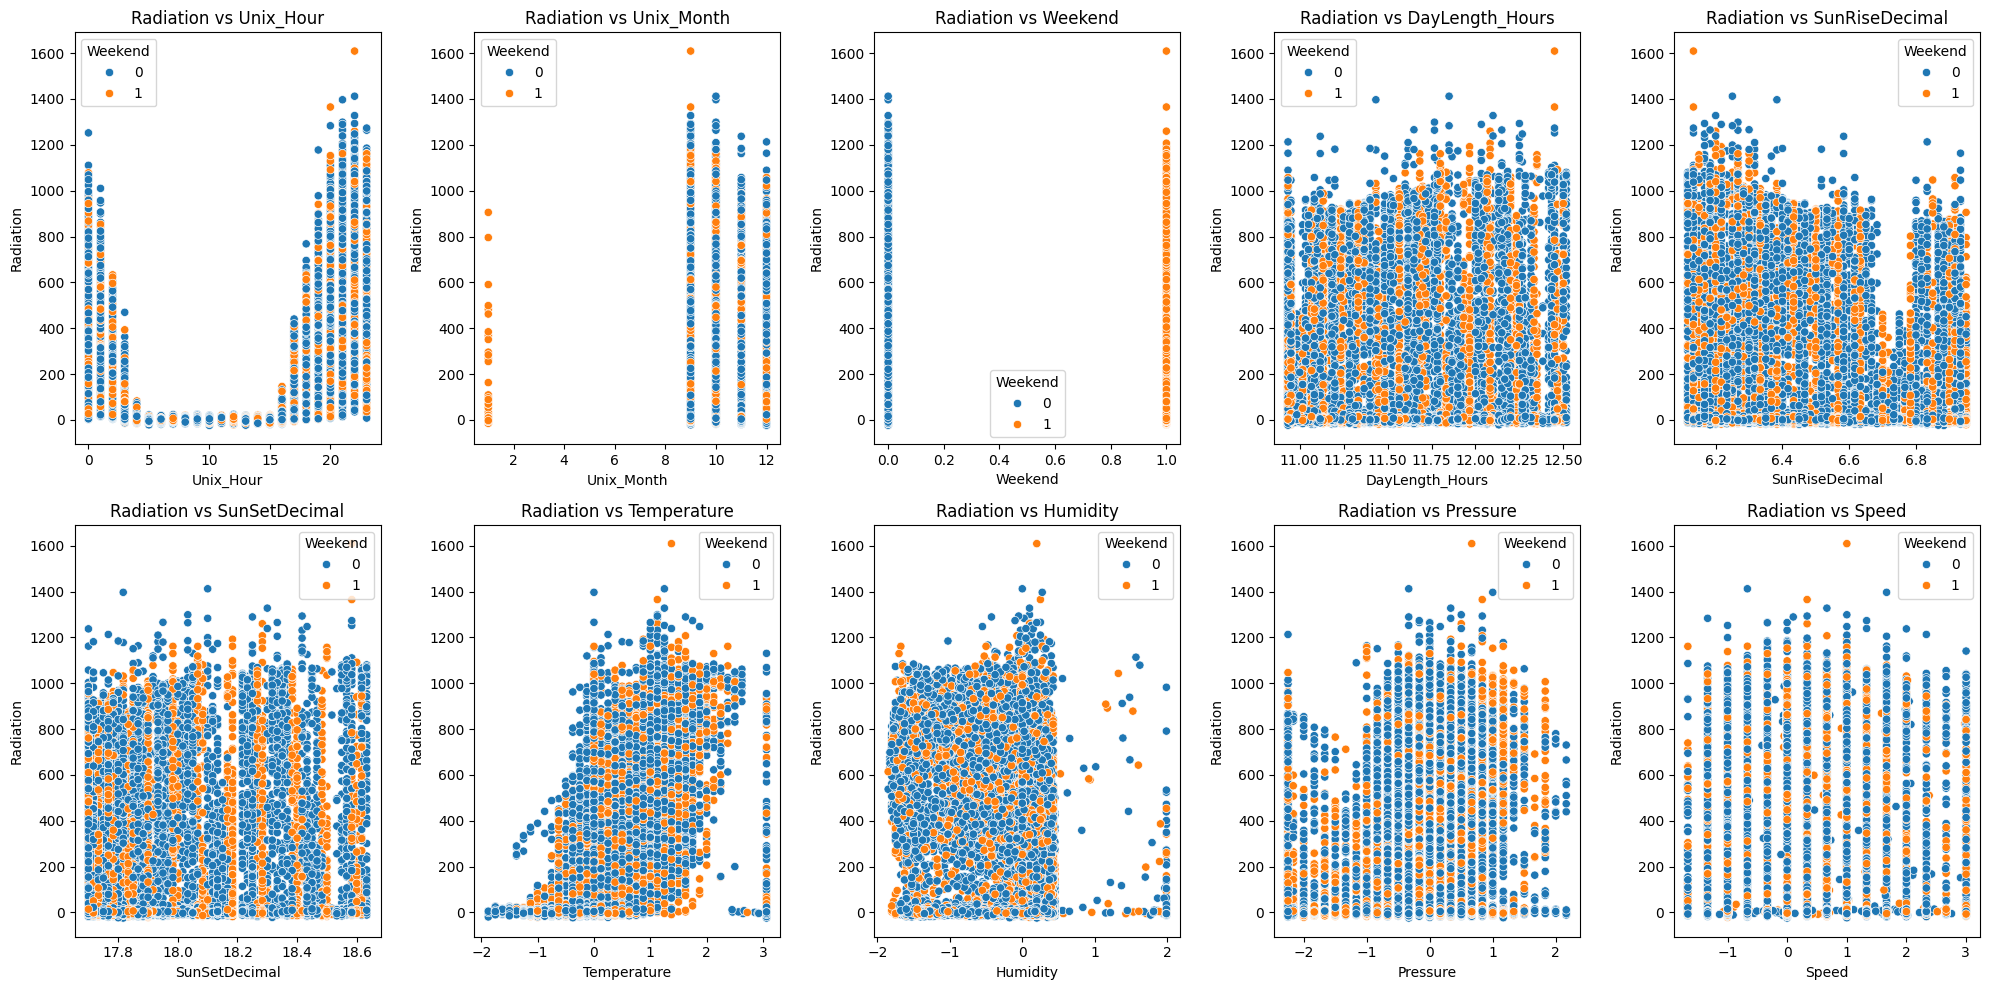

In [240]:
cols = [
    'Unix_Hour',
    'Unix_Month',
    'Weekend',
    'DayLength_Hours',
    'SunRiseDecimal',
    'SunSetDecimal',
    'Temperature',
    'Humidity',
    'Pressure',
    'Speed'
]

fig, axes = plt.subplots(2, 5, figsize=(20,10))

axes = axes.flatten()

for i, col in enumerate(cols):

    sns.scatterplot(
        data=train_df,
        x=col,
        y='Radiation',
        hue='Weekend',
        ax=axes[i]
    )

    axes[i].set_title(f'Radiation vs {col}')

plt.tight_layout()

plt.show()

In [241]:
train_df.columns


Index(['Data', 'Time', 'Radiation', 'Temperature', 'Pressure', 'Humidity',
       'WindDirection(Degrees)', 'Speed', 'TimeSunRise', 'TimeSunSet',
       'Unix_Hour', 'Unix_Month', 'Unix_Week_day', 'Weekend', 'Hour_sin',
       'Hour_cos', 'Month_sin', 'Month_cos', 'DayLength_Hours',
       'SunRiseDecimal', 'SunSetDecimal'],
      dtype='object')

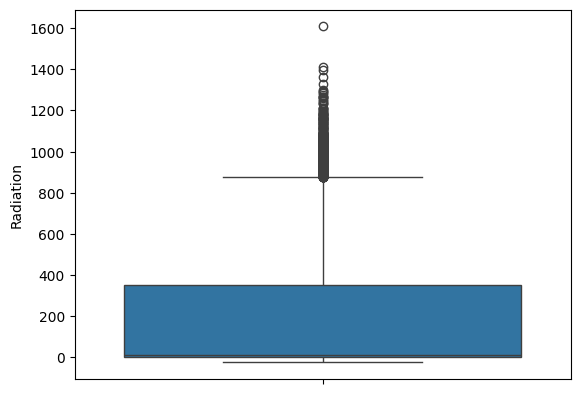

In [242]:
# Fix: Explicitly define y and hue parameters
sns.boxplot(data=train_df, y='Radiation')
plt.show()

In [243]:
train_df

,Data,Time,Radiation,Temperature,Pressure,Humidity,WindDirection(Degrees),Speed,TimeSunRise,TimeSunSet,Unix_Hour,Unix_Month,Unix_Week_day,Weekend,Hour_sin,Hour_cos,Month_sin,Month_cos,DayLength_Hours,SunRiseDecimal,SunSetDecimal
0,2016-10-26,1900-01-01 19:10:19,4.294954,-0.250,-0.333333,0.200,124.57,1.670623,06:21:00,17:52:00,5,10,3,0,0.965926,0.258819,-0.866025,5.000000e-01,11.516667,6.350000,17.866667
1,2016-10-24,1900-01-01 21:15:21,4.439169,-0.375,0.666667,-0.100,148.63,0.000000,06:21:00,17:53:00,7,10,1,0,0.965926,-0.258819,-0.866025,5.000000e-01,11.533333,6.350000,17.883333
2,2016-10-28,1900-01-01 11:20:19,483.267515,0.125,-0.166667,0.375,19.15,-0.667656,06:22:00,17:51:00,21,10,4,0,-0.707107,0.707107,-0.866025,5.000000e-01,11.483333,6.366667,17.850000
3,2016-10-08,1900-01-01 22:40:22,5.950979,0.000,0.000000,0.125,189.05,0.000000,06:15:00,18:05:00,8,10,6,1,0.866025,-0.500000,-0.866025,5.000000e-01,11.833333,6.250000,18.083333
4,2016-10-22,1900-01-01 04:25:17,-8.324804,-0.125,0.000000,0.425,117.63,-0.332344,06:20:00,17:54:00,14,10,5,1,-0.500000,-0.866025,-0.866025,5.000000e-01,11.566667,6.333333,17.900000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19999,2016-09-12,1900-01-01 01:55:18,10.210194,-0.375,0.833333,0.175,177.64,0.335312,06:09:00,18:28:00,11,9,0,0,0.258819,-0.965926,-1.000000,-1.836970e-16,12.316667,6.150000,18.466667
20000,2016-10-07,1900-01-01 12:20:23,323.399022,1.250,0.000000,-0.075,353.49,-0.332344,06:15:00,18:06:00,22,10,4,0,-0.500000,0.866025,-0.866025,5.000000e-01,11.850000,6.250000,18.100000
20001,2016-09-20,1900-01-01 07:55:04,419.397035,0.875,-0.333333,-0.775,80.83,-0.667656,06:11:00,18:21:00,17,9,1,0,-0.965926,-0.258819,-1.000000,-1.836970e-16,12.166667,6.183333,18.350000
20002,2016-09-13,1900-01-01 00:30:08,4.582930,0.000,0.833333,0.175,196.60,0.335312,06:10:00,18:27:00,10,9,1,0,0.500000,-0.866025,-1.000000,-1.836970e-16,12.283333,6.166667,18.450000


In [244]:
train_df.drop(['Data', 'Time'], axis=1, inplace=True)
test_df.drop(['Data', 'Time'], axis=1, inplace=True)

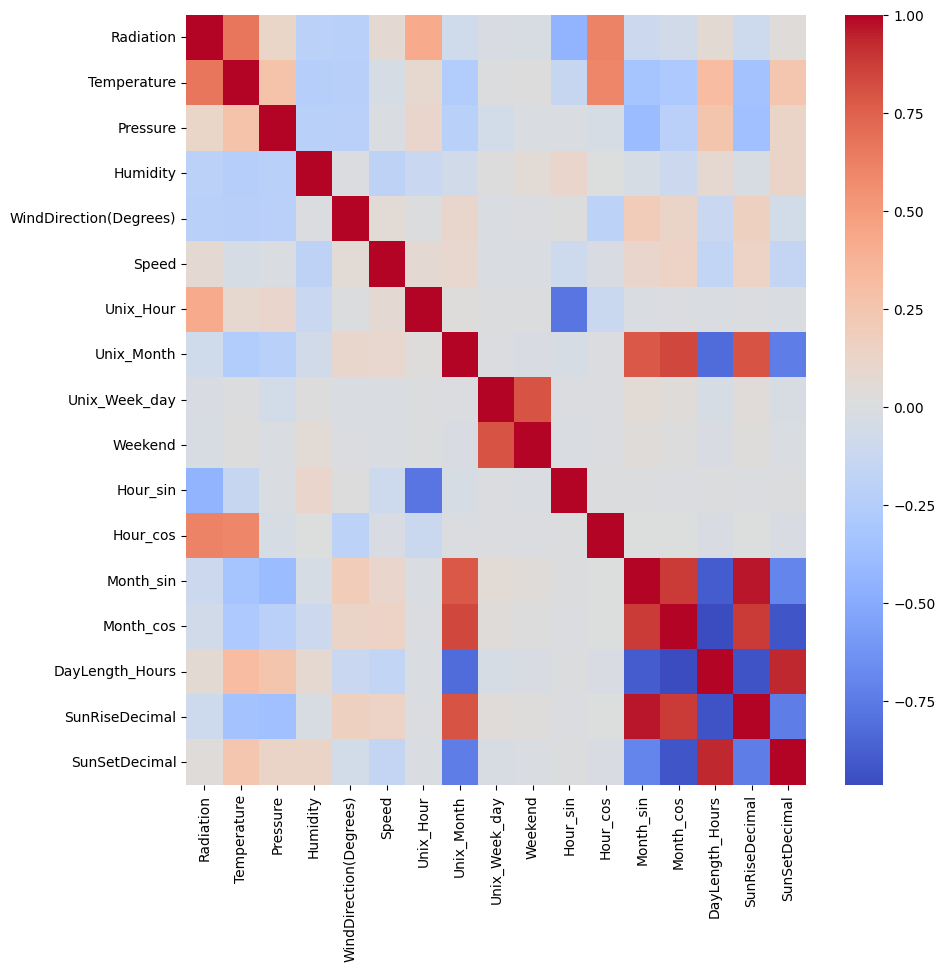

In [245]:
plt.figure(figsize=(10,10))

sns.heatmap(
    train_df.corr(numeric_only=True),
    annot=False,
    cmap="coolwarm"
)

plt.show()

In [246]:
import numpy as np

# ---------------- TRAIN DATA ---------------- #

train_corr_matrix = train_df.corr(numeric_only=True).abs()

train_upper = train_corr_matrix.where(
    np.triu(np.ones(train_corr_matrix.shape), k=1).astype(bool)
)

train_high_corr = [
    column for column in train_upper.columns
    if any(train_upper[column] > 0.90)
]

print("Highly correlated features in train_df:")
print(train_high_corr)

# ---------------- TEST DATA ---------------- #

test_corr_matrix = test_df.corr(numeric_only=True).abs()

test_upper = test_corr_matrix.where(
    np.triu(np.ones(test_corr_matrix.shape), k=1).astype(bool)
)

test_high_corr = [
    column for column in test_upper.columns
    if any(test_upper[column] > 0.9)
]

print("\nHighly correlated features in test_df:")
print(test_high_corr)

Highly correlated features in train_df:
['DayLength_Hours', 'SunRiseDecimal', 'SunSetDecimal']

Highly correlated features in test_df:
['DayLength_Hours', 'SunRiseDecimal', 'SunSetDecimal']


In [247]:
cols_to_drop = train_high_corr

train_df.drop(cols_to_drop, axis=1, inplace=True)
test_df.drop(cols_to_drop, axis=1, inplace=True)

In [248]:
train_df

,Radiation,Temperature,Pressure,Humidity,WindDirection(Degrees),Speed,TimeSunRise,TimeSunSet,Unix_Hour,Unix_Month,Unix_Week_day,Weekend,Hour_sin,Hour_cos,Month_sin,Month_cos
0,4.294954,-0.250,-0.333333,0.200,124.57,1.670623,06:21:00,17:52:00,5,10,3,0,0.965926,0.258819,-0.866025,5.000000e-01
1,4.439169,-0.375,0.666667,-0.100,148.63,0.000000,06:21:00,17:53:00,7,10,1,0,0.965926,-0.258819,-0.866025,5.000000e-01
2,483.267515,0.125,-0.166667,0.375,19.15,-0.667656,06:22:00,17:51:00,21,10,4,0,-0.707107,0.707107,-0.866025,5.000000e-01
3,5.950979,0.000,0.000000,0.125,189.05,0.000000,06:15:00,18:05:00,8,10,6,1,0.866025,-0.500000,-0.866025,5.000000e-01
4,-8.324804,-0.125,0.000000,0.425,117.63,-0.332344,06:20:00,17:54:00,14,10,5,1,-0.500000,-0.866025,-0.866025,5.000000e-01
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19999,10.210194,-0.375,0.833333,0.175,177.64,0.335312,06:09:00,18:28:00,11,9,0,0,0.258819,-0.965926,-1.000000,-1.836970e-16
20000,323.399022,1.250,0.000000,-0.075,353.49,-0.332344,06:15:00,18:06:00,22,10,4,0,-0.500000,0.866025,-0.866025,5.000000e-01
20001,419.397035,0.875,-0.333333,-0.775,80.83,-0.667656,06:11:00,18:21:00,17,9,1,0,-0.965926,-0.258819,-1.000000,-1.836970e-16
20002,4.582930,0.000,0.833333,0.175,196.60,0.335312,06:10:00,18:27:00,10,9,1,0,0.500000,-0.866025,-1.000000,-1.836970e-16


In [249]:
sunrise_test = pd.to_datetime(
    test_df['TimeSunRise'].astype(str)
)

sunset_test = pd.to_datetime(
    test_df['TimeSunSet'].astype(str)
)

test_df['TimeSunRise'] = (
    sunrise_test.dt.hour
    + sunrise_test.dt.minute / 60
)

test_df['TimeSunSet'] = (
    sunset_test.dt.hour
    + sunset_test.dt.minute / 60
)

C:\Users\ashis\AppData\Local\Temp\ipykernel_16440\417195030.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  sunrise_test = pd.to_datetime(
C:\Users\ashis\AppData\Local\Temp\ipykernel_16440\417195030.py:5: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  sunset_test = pd.to_datetime(


In [250]:
sunrise = pd.to_datetime(
    train_df['TimeSunRise'].astype(str)
)

sunset = pd.to_datetime(
    train_df['TimeSunSet'].astype(str)
)

train_df['TimeSunRise'] = (
    sunrise.dt.hour
    + sunrise.dt.minute / 60
)

train_df['TimeSunSet'] = (
    sunset.dt.hour
    + sunset.dt.minute / 60
)

C:\Users\ashis\AppData\Local\Temp\ipykernel_16440\3894578231.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  sunrise = pd.to_datetime(
C:\Users\ashis\AppData\Local\Temp\ipykernel_16440\3894578231.py:5: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  sunset = pd.to_datetime(


In [251]:
train_df['Hour_sin'] = np.sin(
    2 * np.pi * train_df['Unix_Hour'] / 24
)

train_df['Hour_cos'] = np.cos(
    2 * np.pi * train_df['Unix_Hour'] / 24
)

In [260]:
from sklearn.model_selection import train_test_split

X = train_df.drop(columns=['Radiation'])

y = train_df['Radiation']

X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [261]:
object_cols = X_train.select_dtypes(include='object').columns

print(object_cols)

Index([], dtype='object')


In [263]:
# 1. Separate features (X) and target (y) from your training data


import xgboost as xgb
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

# Initialize your ultimate fine-tuned model configuration on the GPU
model = xgb.XGBRegressor(
    device='cuda',
    learning_rate=0.01,
    max_depth=6,
    n_estimators=4000,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=1,
    random_state=42,
    eval_metric='rmse',
    early_stopping_rounds=100
)

model.fit(
    X_train,
    y_train,
    eval_set=[(X_val, y_val)],
    verbose=100
)

# # Train on the 80% split
# model.fit(X_train, y_train)

# Generate validation predictions to calculate your real metrics
val_predictions = model.predict(X_val)

print("=== Internal Validation Accuracy ===")
print(f"R2 Score: {r2_score(y_val, val_predictions):.4f} (Closer to 1.0 is perfect)")
print(f"RMSE:     {np.sqrt(mean_squared_error(y_val, val_predictions)):.2f} (Average unit error)")

[0]	validation_0-rmse:314.11261


[100]	validation_0-rmse:153.66227
[200]	validation_0-rmse:110.33307
[300]	validation_0-rmse:99.17241
[400]	validation_0-rmse:95.07030
[500]	validation_0-rmse:92.85388
[600]	validation_0-rmse:91.41600
[700]	validation_0-rmse:90.53988
[800]	validation_0-rmse:89.63599
[900]	validation_0-rmse:89.15764
[1000]	validation_0-rmse:88.73236
[1100]	validation_0-rmse:88.36890
[1200]	validation_0-rmse:88.03592
[1300]	validation_0-rmse:87.71649
[1400]	validation_0-rmse:87.50762
[1500]	validation_0-rmse:87.26306
[1600]	validation_0-rmse:87.07997
[1700]	validation_0-rmse:86.91594
[1800]	validation_0-rmse:86.80349
[1900]	validation_0-rmse:86.69048
[2000]	validation_0-rmse:86.64719
[2100]	validation_0-rmse:86.52804
[2200]	validation_0-rmse:86.43984
[2300]	validation_0-rmse:86.37013
[2400]	validation_0-rmse:86.33268
[2500]	validation_0-rmse:86.29613
[2600]	validation_0-rmse:86.24514
[2700]	validation_0-rmse:86.19411
[2800]	validation_0-rmse:86.18307
[2900]	validation_0-rmse:86.18455
[3000]	validation_0-r

In [268]:
import xgboost as xgb
import numpy as np
from sklearn.metrics import mean_squared_error

model = xgb.XGBRegressor(

    device='cuda',

    learning_rate=0.01,

    max_depth=6,

    n_estimators=4000,

    subsample=0.8,

    colsample_bytree=0.8,

    reg_alpha=0.1,

    reg_lambda=1,

    random_state=42,

    eval_metric='rmse',

    early_stopping_rounds=100
)

model.fit(
    X_train,
    y_train,
    eval_set=[(X_val, y_val)],
    verbose=200
)

# Validation prediction
val_predictions = model.predict(X_val)

# RMSE
rmse = np.sqrt(
    mean_squared_error(y_val, val_predictions)
)

print("RMSE:", rmse)

[0]	validation_0-rmse:314.11261
[200]	validation_0-rmse:110.33307
[400]	validation_0-rmse:95.07030
[600]	validation_0-rmse:91.41600
[800]	validation_0-rmse:89.63599
[1000]	validation_0-rmse:88.73236
[1200]	validation_0-rmse:88.03592
[1400]	validation_0-rmse:87.50762
[1600]	validation_0-rmse:87.07997
[1800]	validation_0-rmse:86.80349
[2000]	validation_0-rmse:86.64719
[2200]	validation_0-rmse:86.43984
[2400]	validation_0-rmse:86.33268
[2600]	validation_0-rmse:86.24514
[2800]	validation_0-rmse:86.18307
[3000]	validation_0-rmse:86.12422
[3200]	validation_0-rmse:86.09010
[3266]	validation_0-rmse:86.10596
RMSE: 86.06942587634772


In [ ]:
y_pred = model.predict(test_df)


In [290]:
#  Create submission dataframe
submission = pd.DataFrame({
    'ID': test_df1['ID'],
    'Target': y_pred4
})

# Save submission file
submission.to_csv(
    'submission_4.csv',
    index=False
)

print("submission.csv created successfully")

submission.csv created successfully


In [267]:
from sklearn.model_selection import RandomizedSearchCV
import xgboost as xgb
import numpy as np

# Features and target
X = train_df.drop(columns=['Radiation'])
y = train_df['Radiation']

# Model
xgb_model = xgb.XGBRegressor(
    device='cuda',
    tree_method='hist',
    objective='reg:squarederror',
    eval_metric='rmse',
    random_state=42
)

# Parameter search space
param_dist = {

    'learning_rate': [0.005, 0.01, 0.02, 0.03],

    'max_depth': [3, 4, 5, 6, 7],

    'n_estimators': [500, 1000, 2000, 3000],

    'min_child_weight': [1, 3, 5, 7],

    'subsample': [0.6, 0.7, 0.8, 1.0],

    'colsample_bytree': [0.6, 0.7, 0.8, 1.0],

    'gamma': [0, 0.1, 0.3, 0.5],

    'reg_alpha': [0, 0.1, 0.5, 1],

    'reg_lambda': [1, 2, 5]
}

# Random search
random_search = RandomizedSearchCV(

    estimator=xgb_model,

    param_distributions=param_dist,

    n_iter=25,

    scoring='neg_root_mean_squared_error',

    cv=3,

    verbose=2,

    random_state=42,

    n_jobs=-1
)

# Train
random_search.fit(X, y)

# Best parameters
print("Best Parameters:")
print(random_search.best_params_)

# Best RMSE
print(
    "Best RMSE:",
    -random_search.best_score_
)

Fitting 3 folds for each of 25 candidates, totalling 75 fits
Best Parameters:
{'subsample': 0.6, 'reg_lambda': 1, 'reg_alpha': 1, 'n_estimators': 3000, 'min_child_weight': 3, 'max_depth': 7, 'learning_rate': 0.005, 'gamma': 0, 'colsample_bytree': 0.8}
Best RMSE: 88.28896788910454


In [264]:
print("train_df shape:", train_df.shape)

print("test_df shape:", test_df.shape)

print("test_df1 shape:", test_df1.shape)

print("X_train shape:", X_train.shape)

print("X_val shape:", X_val.shape)

print("y_train shape:", y_train.shape)

print("y_val shape:", y_val.shape)

train_df shape: (19747, 16)
test_df shape: (3334, 15)
test_df1 shape: (3334, 11)
X_train shape: (15797, 15)
X_val shape: (3950, 15)
y_train shape: (15797,)
y_val shape: (3950,)


In [ ]:
y_pred

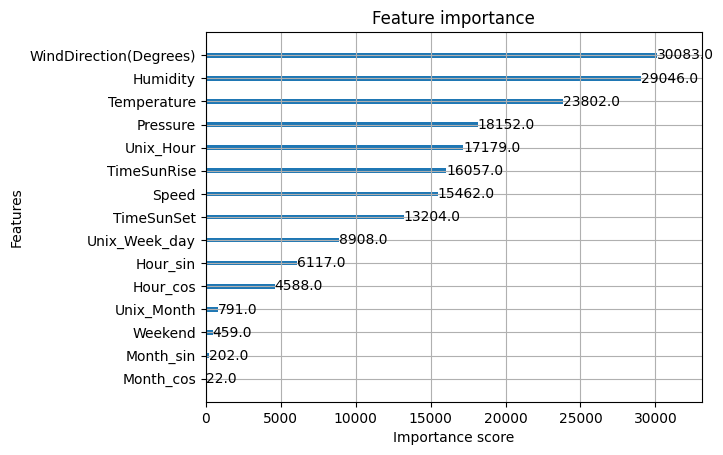

In [273]:
xgb.plot_importance(model)

plt.show()

In [277]:
from catboost import CatBoostRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
import numpy as np

# Features and target
X = train_df.drop(columns=['Radiation'])

y = train_df['Radiation']

# Validation split
X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# CatBoost model
model = CatBoostRegressor(

    task_type='GPU',

    iterations=8000,

    learning_rate=0.01,

    depth=5,

    l2_leaf_reg=5,

    bagging_temperature=1,

    random_strength=1,

    loss_function='RMSE',

    eval_metric='RMSE',

    random_seed=42,

    verbose=200
)

# Train
model.fit(
    X_train,
    y_train,
    eval_set=(X_val, y_val),
    use_best_model=True
)

# Predict
val_predictions = model.predict(X_val)

# RMSE
rmse = np.sqrt(
    mean_squared_error(y_val, val_predictions)
)

print("RMSE:", rmse)

0:	learn: 311.1513692	test: 314.3813310	best: 314.3813310 (0)	total: 12.9ms	remaining: 1m 43s
200:	learn: 124.9075217	test: 127.6501548	best: 127.6501548 (200)	total: 2.39s	remaining: 1m 32s
400:	learn: 109.2377383	test: 113.3089961	best: 113.3089961 (400)	total: 4.8s	remaining: 1m 31s
600:	learn: 104.1508589	test: 108.7934101	best: 108.7934101 (600)	total: 7.2s	remaining: 1m 28s
800:	learn: 101.0015001	test: 106.1048395	best: 106.1048395 (800)	total: 9.65s	remaining: 1m 26s
1000:	learn: 98.3365193	test: 103.9430272	best: 103.9430272 (1000)	total: 12s	remaining: 1m 23s
1200:	learn: 96.2538371	test: 102.3639573	best: 102.3639573 (1200)	total: 14.2s	remaining: 1m 20s
1400:	learn: 94.4187149	test: 100.9861853	best: 100.9861853 (1400)	total: 16.5s	remaining: 1m 17s
1600:	learn: 92.8539324	test: 99.8786910	best: 99.8786910 (1600)	total: 18.9s	remaining: 1m 15s
1800:	learn: 91.5175152	test: 98.9705083	best: 98.9705083 (1800)	total: 21.5s	remaining: 1m 13s
2000:	learn: 90.3239974	test: 98.096

In [286]:
y_pred2 = model.predict(test_df)

In [282]:
import lightgbm as lgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
import numpy as np

# Features and target
X = train_df.drop(columns=['Radiation'])

y = train_df['Radiation']

# Split
X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Model
model = lgb.LGBMRegressor(

    device='gpu',

    learning_rate=0.01,

    n_estimators=6000,

    max_depth=5,

    num_leaves=31,

    subsample=0.8,

    colsample_bytree=0.8,

    reg_alpha=0.1,

    reg_lambda=1,

    random_state=42
)

# Train
model.fit(
    X_train,
    y_train,
    eval_set=[(X_val, y_val)]
)

# Predict
val_predictions = model.predict(X_val)

# RMSE
rmse = np.sqrt(
    mean_squared_error(y_val, val_predictions)
)

print("RMSE:", rmse)


[LightGBM] [Info] This is the GPU trainer!!
[LightGBM] [Info] Total Bins 677
[LightGBM] [Info] Number of data points in the train set: 15797, number of used features: 15
[LightGBM] [Info] Using GPU Device: NVIDIA GeForce RTX 2050, Vendor: NVIDIA Corporation
[LightGBM] [Info] Compiling OpenCL Kernel with 256 bins...
[LightGBM] [Info] GPU programs have been built
[LightGBM] [Info] Size of histogram bin entry: 8
[LightGBM] [Info] 14 dense feature groups (0.24 MB) transferred to GPU in 0.002064 secs. 1 sparse feature groups
[LightGBM] [Info] Start training from score 204.826561
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with 

In [288]:
from skopt import BayesSearchCV
from skopt.space import Real, Integer

import xgboost as xgb
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

# Features and target
X = train_df.drop(columns=['Radiation'])

y = train_df['Radiation']

# Split
X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# XGBoost model
xgb_model = xgb.XGBRegressor(

    device='cuda',

    tree_method='hist',

    objective='reg:squarederror',

    eval_metric='rmse',

    random_state=42
)

# Bayesian search space
param_space = {

    'learning_rate': Real(
        0.005,
        0.05,
        prior='log-uniform'
    ),

    'max_depth': Integer(
        3,
        8
    ),

    'n_estimators': Integer(
        500,
        5000
    ),

    'min_child_weight': Integer(
        1,
        10
    ),

    'subsample': Real(
        0.6,
        1.0
    ),

    'colsample_bytree': Real(
        0.6,
        1.0
    ),

    'gamma': Real(
        0,
        2
    ),

    'reg_alpha': Real(
        0,
        5
    ),

    'reg_lambda': Real(
        0.5,
        5
    )
}

# Bayesian optimization
bayes_search = BayesSearchCV(

    estimator=xgb_model,

    search_spaces=param_space,

    n_iter=30,

    scoring='neg_root_mean_squared_error',

    cv=3,

    verbose=2,

    n_jobs=-1,

    random_state=42
)

# Train
bayes_search.fit(X_train, y_train)

# Best parameters
print("Best Parameters:")
print(bayes_search.best_params_)

# Best score
print(
    "Best RMSE:",
    -bayes_search.best_score_
)

# Validation prediction
best_model = bayes_search.best_estimator_

val_predictions = best_model.predict(X_val)

# Final RMSE
rmse = np.sqrt(
    mean_squared_error(y_val, val_predictions)
)

print("Validation RMSE:", rmse)

Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fi

In [289]:
y_pred4 = bayes_search.predict(test_df)